# Cross-match masivas × VSX (AAVSO Variable Star Index)

Mismo patrón que el cross-match OGLE×TIC del notebook `1_..._preparate_data_OGLE`:
`astroquery.xmatch.XMatch` (CDS) a **2″**, dedup por `angDist` mínimo.

Aquí NO se descargan curvas nuevas: las masivas ya tienen sus LCs en
`lightcurves_all.parquet` y sus peaks en `peaks.parquet`. El objetivo es solo
obtener `Type` y `Period` de VSX (`vizier:B/vsx/vsx`) para usarlos como
benchmark independiente en `2_Github_TESS_variability_VSX.ipynb`.

Salida: `catalogs/1_MassiveXVSX.csv` (una fila por GaiaDR3 con match VSX).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.table import Table
from astroquery.xmatch import XMatch

from msv import config

CLEAN_CSV = config.CATALOGS_DIR / "3_MassiveXTessV8_LC_DeltaMagnitude_Clean.csv"
OUT_CSV = config.CATALOGS_DIR / "1_MassiveXVSX.csv"

df_mas = pd.read_csv(CLEAN_CSV)
print(f"masivas limpias: {len(df_mas)} filas | GaiaDR3 únicos: {df_mas['GaiaDR3'].nunique()}")

Could not import regions, which is required for some of the functionalities of this module.


masivas limpias: 3578 filas | GaiaDR3 únicos: 3578


## X-Match contra `B/vsx/vsx` a 2″

In [2]:
cat1 = Table.from_pandas(
    df_mas[["GaiaDR3", "TIC", "ra", "dec", "Tmag", "Gmag"]].drop_duplicates("GaiaDR3"))

res = XMatch.query(cat1=cat1, cat2="vizier:B/vsx/vsx",
                   max_distance=2 * u.arcsec, colRA1="ra", colDec1="dec")
xm = res.to_pandas()
print(f"matches crudos: {len(xm)} | GaiaDR3 únicos: {xm['GaiaDR3'].nunique()}")

matches crudos: 1152 | GaiaDR3 únicos: 1152


## Dedup: contraparte VSX más cercana por estrella

Mismo criterio que en OGLE×TIC — si una estrella tiene más de una contraparte
dentro de 2″, se queda con la de `angDist` mínimo.

In [3]:
xm = xm.sort_values("angDist").drop_duplicates("GaiaDR3").reset_index(drop=True)
print(f"tras dedup: {len(xm)} estrellas con contraparte VSX")
print(f"con Period definido: {xm['Period'].notna().sum()}")

xm.to_csv(OUT_CSV, index=False)
print(f"-> {OUT_CSV}")

tras dedup: 1152 estrellas con contraparte VSX
con Period definido: 567
-> /home/nicolas/nico/git/MassiveStarVariability/catalogs/1_MassiveXVSX.csv


## Reporte del match

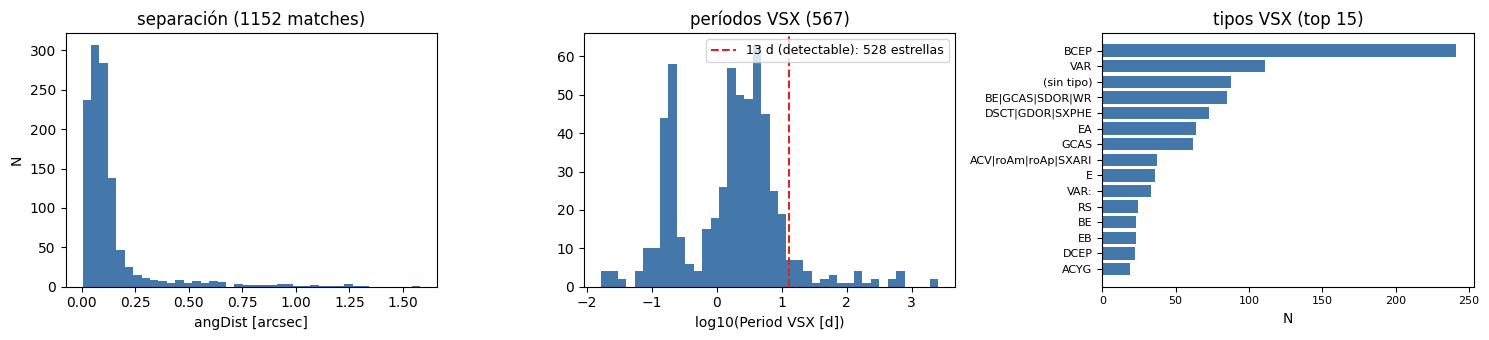

Type
BCEP                   241
VAR                    111
                        88
BE|GCAS|SDOR|WR         85
DSCT|GDOR|SXPHE         73
EA                      64
GCAS                    62
ACV|roAm|roAp|SXARI     37
E                       36
VAR:                    33
RS                      24
BE                      23
EB                      23
DCEP                    22
ACYG                    19
ELL                     18
MISC                    14
ACYG:                   10
EA/DM                   10
EB/DM                    8
ESD                      7
SPB:                     7
BCEP:                    6
EA+BCEP                  6
DCEPS                    6


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(xm["angDist"], bins=40, color="#4477AA")
axes[0].set_xlabel("angDist [arcsec]"); axes[0].set_ylabel("N")
axes[0].set_title(f"separación ({len(xm)} matches)")

per = xm["Period"].dropna()
axes[1].hist(np.log10(per), bins=40, color="#4477AA")
axes[1].axvline(np.log10(13), color="tab:red", ls="--",
                label=f"13 d (detectable): {(per < 13).sum()} estrellas")
axes[1].set_xlabel("log10(Period VSX [d])"); axes[1].legend(fontsize=9)
axes[1].set_title(f"períodos VSX ({len(per)})")

vc = xm["Type"].fillna("(sin tipo)").replace("", "(sin tipo)").value_counts().head(15)
axes[2].barh(vc.index[::-1], vc.values[::-1], color="#4477AA")
axes[2].set_xlabel("N"); axes[2].set_title("tipos VSX (top 15)")
axes[2].tick_params(labelsize=8)

plt.tight_layout(); plt.show()

print(xm["Type"].value_counts().head(25).to_string())